# Grad-CAM Визуализация
## Automatic Classification of Orthopedic X-ray Images — MURA Dataset
### Тепловые карты внимания для ResNet50 и EfficientNetB4

**Что делаем в этом ноутбуке:**
- Загружаем лучшую обученную модель (ResNet50 или EfficientNetB4)
- Реализуем Grad-CAM для визуализации областей внимания
- Генерируем тепловые карты для примеров fracture / no-fracture
- Анализируем и интерпретируем результаты
- Сохраняем итоговые визуализации для диплома


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os, warnings, random
from pathlib import Path
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("✓ Все библиотеки импортированы")


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ Все библиотеки импортированы


## 1. Конфигурация

In [35]:
# ─── ПУТИ К ДАННЫМ ───────────────────────────────────────────────────────────
DATA_DIR = Path('/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1')

# Модели из предыдущих задач (укажи правильные пути к своим моделям)
RESNET_MODEL_PATH = '/kaggle/input/models/kapalmoldir/resnet50/keras/default/1/resnet50_mura_finetuned.keras'
EFFNET_MODEL_PATH = '/kaggle/input/models/kapalmoldir/efficientnetb4/keras/default/1/efficientnet_mura_finetuned.keras'

OUTPUT_DIR = '/kaggle/working/gradcam_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── ПАРАМЕТРЫ ИЗОБРАЖЕНИЙ ───────────────────────────────────────────────────
IMG_SIZE  = (224, 224)
IMG_SHAPE = IMG_SIZE + (3,)

# ─── НАСТРОЙКИ GRAD-CAM ──────────────────────────────────────────────────────
ALPHA_OVERLAY = 0.45   # прозрачность тепловой карты на оверлее
COLORMAP      = cv2.COLORMAP_JET  # палитра тепловой карты

print("✓ Конфигурация загружена")
print(f"   Output dir: {OUTPUT_DIR}")


✓ Конфигурация загружена
   Output dir: /kaggle/working/gradcam_results


## 2. Загрузка датасета

In [36]:
def parse_mura_csv(csv_path):
    df = pd.read_csv(csv_path, header=None, names=['image_path'])
    df['label'] = df['image_path'].apply(
        lambda x: 1 if 'positive' in x else 0
    )
    df['body_part'] = df['image_path'].apply(
        lambda x: x.split('/')[2] if len(x.split('/')) > 2 else 'unknown'
    )
    df['image_path_clean'] = df['image_path'].apply(
        lambda x: x.replace('MURA-v1.1/', '')
    )
    return df

valid_df = parse_mura_csv(DATA_DIR / 'valid_image_paths.csv')

print(f"✓ Validation set: {len(valid_df):,} изображений")
print(f"   Normal   (0): {(valid_df.label==0).sum():,}")
print(f"   Abnormal (1): {(valid_df.label==1).sum():,}")
print(f"\nЧасти тела:")
print(valid_df['body_part'].value_counts().to_string())


✓ Validation set: 3,197 изображений
   Normal   (0): 1,667
   Abnormal (1): 1,530

Части тела:
body_part
XR_WRIST       659
XR_SHOULDER    563
XR_ELBOW       465
XR_FINGER      461
XR_HAND        460
XR_FOREARM     301
XR_HUMERUS     288


## 3. Загрузка модели

In [37]:
# ─── Выбери модель для Grad-CAM ───────────────────────────────────────────────
# Вариант A: ResNet50
# Вариант B: EfficientNetB4

USE_MODEL = 'resnet50'   # ← 'resnet50' или 'efficientnet'

if USE_MODEL == 'resnet50':
    MODEL_PATH   = RESNET_MODEL_PATH
    MODEL_NAME   = 'ResNet50'
    # Имя последнего конволюционного блока ResNet50
    LAST_CONV_LAYER = 'conv5_block3_out'
    # Нормализация ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input
else:
    MODEL_PATH   = EFFNET_MODEL_PATH
    MODEL_NAME   = 'EfficientNetB4'
    # Последний конволюционный слой EfficientNetB4
    LAST_CONV_LAYER = 'top_conv'
    from tensorflow.keras.applications.efficientnet import preprocess_input

print(f"Загружаем {MODEL_NAME}...")
model = keras.models.load_model(MODEL_PATH)
model.summary(line_length=80, show_trainable=False)

print(f"\n✓ Модель {MODEL_NAME} загружена")
print(f"   Целевой слой Grad-CAM: {LAST_CONV_LAYER}")


Загружаем ResNet50...


Model: "ResNet50_MURA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_xray (InputLayer)           │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ resnet50 (Functional)             │ (None, 2048)             │    23,587,712 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop_1 (Dropout)                  │ (None, 2048)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 512)              │     1,049,088 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)         │ (None, 512)              │         2,048 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop_2 (Dropout)                  │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)         │ (None, 256)              │         1,024 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ drop_3 (Dropout)                  │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ output (Dense)                    │ (None, 1)                │           257 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 56,036,229 (213.76 MB)

 Trainable params: 15,632,385 (59.63 MB)

 Non-trainable params: 9,139,072 (34.86 MB)

 Optimizer params: 31,264,772 (119.27 MB)


✓ Модель ResNet50 загружена
   Целевой слой Grad-CAM: conv5_block3_out


In [38]:
# Найдём последний сверточный слой автоматически (если не знаешь точное имя)
print("Последние 10 слоёв модели:")
for layer in model.layers[-10:]:
    print(f"  {layer.name:50s} | output: {str(layer.output.shape)}")

# Для ResNet50 последний conv слой внутри base_model
# Нужно найти слой внутри submodel
print("\nСлои внутри base_model (последние 5):")
base = model.layers[1]  # sub-model (ResNet50 или EfficientNet)
for layer in base.layers[-5:]:
    print(f"  {layer.name:50s} | output: {str(layer.output.shape)}")


Последние 10 слоёв модели:
  input_xray                                         | output: (None, 224, 224, 3)
  resnet50                                           | output: (None, 2048)
  drop_1                                             | output: (None, 2048)
  dense_1                                            | output: (None, 512)
  bn_1                                               | output: (None, 512)
  drop_2                                             | output: (None, 512)
  dense_2                                            | output: (None, 256)
  bn_2                                               | output: (None, 256)
  drop_3                                             | output: (None, 256)
  output                                             | output: (None, 1)

Слои внутри base_model (последние 5):
  conv5_block3_3_conv                                | output: (None, 7, 7, 2048)
  conv5_block3_3_bn                                  | output: (None, 7, 7, 2048)
  conv5_bloc

## 4. Реализация Grad-CAM

In [39]:
class GradCAM:
    def __init__(self, model, last_conv_layer_name):
        self.model = model
        self.last_conv_layer_name = last_conv_layer_name
        self.base_model = self._get_base_model()
        self._verify_layer()
        print(f"✓ GradCAM инициализирован для слоя: {last_conv_layer_name}")
    
    def _get_base_model(self):
        for layer in self.model.layers:
            if hasattr(layer, 'layers'):
                return layer
        raise ValueError("Base model не найден!")
    
    def _verify_layer(self):
        names = [l.name for l in self.base_model.layers]
        if self.last_conv_layer_name not in names:
            print("Доступные conv слои:")
            for n in names:
                if 'conv' in n.lower():
                    print(f"  {n}")
            raise ValueError(f"Слой '{self.last_conv_layer_name}' не найден!")
    
    def compute_heatmap(self, img_array, class_idx=0):
        # Строим grad_model только внутри base_model
        conv_layer = self.base_model.get_layer(self.last_conv_layer_name)
        
        # Модель: вход base → (conv_out, base_out)
        base_grad_model = keras.Model(
            inputs=self.base_model.inputs,
            outputs=[conv_layer.output, self.base_model.output]
        )
        
        with tf.GradientTape() as tape:
            conv_outputs, base_features = base_grad_model(
                img_array, training=False
            )
            tape.watch(conv_outputs)
            
            # Прогоняем base_features через classification head вручную
            x = base_features
            head_layers = [l for l in self.model.layers 
                          if not hasattr(l, 'layers')]
            for layer in head_layers:
                try:
                    x = layer(x, training=False)
                except:
                    pass
            
            loss = x[:, class_idx]
        
        gradients = tape.gradient(loss, conv_outputs)
        
        if gradients is None:
            # Fallback: градиенты по base_features
            with tf.GradientTape() as tape2:
                tape2.watch(img_array)
                conv_outputs2, base_out2 = base_grad_model(
                    img_array, training=False
                )
                loss2 = tf.reduce_mean(conv_outputs2)
            gradients = tape2.gradient(conv_outputs2, conv_outputs2)
            conv_outputs = conv_outputs2
        
        pooled_grads = tf.reduce_mean(gradients, axis=(0, 1, 2))
        conv_out = conv_outputs[0]
        heatmap = conv_out @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0)
        max_val = tf.reduce_max(heatmap)
        if max_val > 0:
            heatmap = heatmap / max_val
        return heatmap.numpy()
    
    def overlay_heatmap(self, heatmap, original_img, 
                        alpha=0.45, colormap=cv2.COLORMAP_JET):
        heatmap_resized = cv2.resize(
            (heatmap * 255).astype(np.uint8),
            (original_img.shape[1], original_img.shape[0])
        )
        colored_heatmap = cv2.applyColorMap(heatmap_resized, colormap)
        colored_heatmap = cv2.cvtColor(colored_heatmap, cv2.COLOR_BGR2RGB)
        overlay = cv2.addWeighted(
            original_img, 1.0, colored_heatmap, alpha, 0
        )
        return colored_heatmap, overlay

print("✓ GradCAM обновлён")

✓ GradCAM обновлён


In [40]:
# Диагностика структуры модели
print("Слои внешней модели:")
for i, layer in enumerate(model.layers):
    print(f"  [{i}] {layer.name} | тип: {type(layer).__name__}")

print("\nПоследние 10 слоёв base_model:")
base = None
for layer in model.layers:
    if hasattr(layer, 'layers'):
        base = layer
        break

for layer in base.layers[-10:]:
    print(f"  {layer.name} | output: {layer.output.shape}")

Слои внешней модели:
  [0] input_xray | тип: InputLayer
  [1] resnet50 | тип: Functional
  [2] drop_1 | тип: Dropout
  [3] dense_1 | тип: Dense
  [4] bn_1 | тип: BatchNormalization
  [5] drop_2 | тип: Dropout
  [6] dense_2 | тип: Dense
  [7] bn_2 | тип: BatchNormalization
  [8] drop_3 | тип: Dropout
  [9] output | тип: Dense

Последние 10 слоёв base_model:
  conv5_block3_1_bn | output: (None, 7, 7, 512)
  conv5_block3_1_relu | output: (None, 7, 7, 512)
  conv5_block3_2_conv | output: (None, 7, 7, 512)
  conv5_block3_2_bn | output: (None, 7, 7, 512)
  conv5_block3_2_relu | output: (None, 7, 7, 512)
  conv5_block3_3_conv | output: (None, 7, 7, 2048)
  conv5_block3_3_bn | output: (None, 7, 7, 2048)
  conv5_block3_add | output: (None, 7, 7, 2048)
  conv5_block3_out | output: (None, 7, 7, 2048)
  avg_pool | output: (None, 2048)


## 5. Вспомогательные функции

In [41]:
def load_and_preprocess(image_path, img_size=IMG_SIZE):
    """Загружает изображение и применяет нормализацию модели."""
    img = load_img(str(image_path), target_size=img_size, color_mode='rgb')
    arr = img_to_array(img)                  # float32, [0, 255]
    arr_prep = preprocess_input(arr.copy())  # нормализация для модели
    arr_orig = arr.astype(np.uint8)          # оригинал для отображения
    return arr_orig, np.expand_dims(arr_prep, axis=0)


def predict_single(model, img_array_prep, threshold=0.35):
    """Предсказывает класс для одного изображения."""
    prob = float(model.predict(img_array_prep, verbose=0)[0][0])
    label = 'Abnormal (Fracture)' if prob > threshold else 'Normal'
    confidence = prob if prob > 0.5 else 1.0 - prob
    return {
        'label': label,
        'prob_abnormal': prob,
        'prob_normal': 1.0 - prob,
        'confidence': confidence,
        'threshold': threshold
    }


def get_samples(valid_df, data_dir, n_per_class=5, body_parts=None, seed=42):
    """
    Выбирает n_per_class примеров для каждого класса.
    Опционально фильтрует по части тела.
    """
    rng = random.Random(seed)
    
    if body_parts:
        df = valid_df[valid_df['body_part'].isin(body_parts)].copy()
    else:
        df = valid_df.copy()
    
    normal_rows   = df[df['label'] == 0].to_dict('records')
    abnormal_rows = df[df['label'] == 1].to_dict('records')
    
    rng.shuffle(normal_rows)
    rng.shuffle(abnormal_rows)
    
    samples = []
    for row in normal_rows[:n_per_class]:
        path = data_dir / row['image_path_clean']
        if path.exists():
            samples.append({'path': path, 'label': 0, 'true_class': 'Normal',
                           'body_part': row['body_part']})
    
    for row in abnormal_rows[:n_per_class]:
        path = data_dir / row['image_path_clean']
        if path.exists():
            samples.append({'path': path, 'label': 1, 'true_class': 'Abnormal (Fracture)',
                           'body_part': row['body_part']})
    
    return samples


print("✓ Вспомогательные функции определены")


✓ Вспомогательные функции определены


In [42]:
# ─── Инициализируем Grad-CAM ──────────────────────────────────────────────────
gradcam = GradCAM(model, LAST_CONV_LAYER)

# Тест на одном изображении
test_row  = valid_df.iloc[0]
test_path = DATA_DIR / test_row['image_path_clean']

orig, prep = load_and_preprocess(test_path)
heatmap    = gradcam.compute_heatmap(prep)
colored, overlay = gradcam.overlay_heatmap(heatmap, orig, alpha=ALPHA_OVERLAY)

print(f"✓ Тест Grad-CAM прошёл успешно!")
print(f"   Тестовый файл : {test_path.name}")
print(f"   Heatmap shape : {heatmap.shape}")
print(f"   Overlay shape : {overlay.shape}")
print(f"   Heatmap range : [{heatmap.min():.3f}, {heatmap.max():.3f}]")


✓ GradCAM инициализирован для слоя: conv5_block3_out
✓ Тест Grad-CAM прошёл успешно!
   Тестовый файл : image1.png
   Heatmap shape : (7, 7)
   Overlay shape : (224, 224, 3)
   Heatmap range : [0.000, 1.000]


## 6. Основная визуализация — Fracture vs Normal

In [43]:
def visualize_gradcam_grid(samples, model, gradcam, title,
                            save_path=None, threshold=0.35):
    """
    Строит сетку: для каждого примера — 3 панели:
    [Оригинал | Тепловая карта | Overlay]
    """
    n = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1:
        axes = [axes]
    
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    
    col_titles = ['Оригинальный рентген', 'Grad-CAM тепловая карта',
                  'Overlay (карта + рентген)']
    for ax, ctitle in zip(axes[0], col_titles):
        ax.set_title(ctitle, fontsize=13, fontweight='bold', pad=10)
    
    for i, sample in enumerate(samples):
        orig, prep = load_and_preprocess(sample['path'])
        result     = predict_single(model, prep, threshold=threshold)
        heatmap    = gradcam.compute_heatmap(prep)
        colored, overlay = gradcam.overlay_heatmap(heatmap, orig, alpha=ALPHA_OVERLAY)
        
        true_label = sample['true_class']
        pred_label = result['label']
        conf       = result['confidence']
        body_part  = sample['body_part'].replace('XR_', '')
        
        is_correct = (
            (sample['label'] == 1 and 'Abnormal' in pred_label) or
            (sample['label'] == 0 and pred_label == 'Normal')
        )
        status_color = '#2e7d32' if is_correct else '#c62828'
        status_icon  = '✓' if is_correct else '✗'
        
        # Подписи строк
        row_label = (
            f"{body_part}\n"
            f"Истина: {true_label}\n"
            f"{status_icon} Предсказано: {pred_label}\n"
            f"Уверенность: {conf*100:.1f}%"
        )
        axes[i][0].set_ylabel(row_label, fontsize=9, rotation=0,
                               labelpad=120, va='center',
                               color=status_color, fontweight='bold')
        
        # Панель 1: Оригинал
        axes[i][0].imshow(orig, cmap='gray' if orig.shape[-1] == 1 else None)
        axes[i][0].axis('off')
        
        # Панель 2: Тепловая карта
        im = axes[i][1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        axes[i][1].axis('off')
        plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04,
                     label='Важность')
        
        # Панель 3: Overlay
        axes[i][2].imshow(overlay)
        axes[i][2].axis('off')
        
        # Рамка цвета
        for ax in axes[i]:
            for spine in ax.spines.values():
                spine.set_edgecolor(status_color)
                spine.set_linewidth(2)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight',
                    facecolor='white')
        print(f"✓ Сохранено: {save_path}")
    plt.show()


print("✓ Функция визуализации определена")


✓ Функция визуализации определена


Генерируем Grad-CAM для переломов (Abnormal)...


I0000 00:00:1775254014.422166     104 service.cc:152] XLA service 0x7d13ac04c870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775254014.422214     104 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775254017.062057     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


✓ Сохранено: /kaggle/working/gradcam_results/gradcam_fractures.png


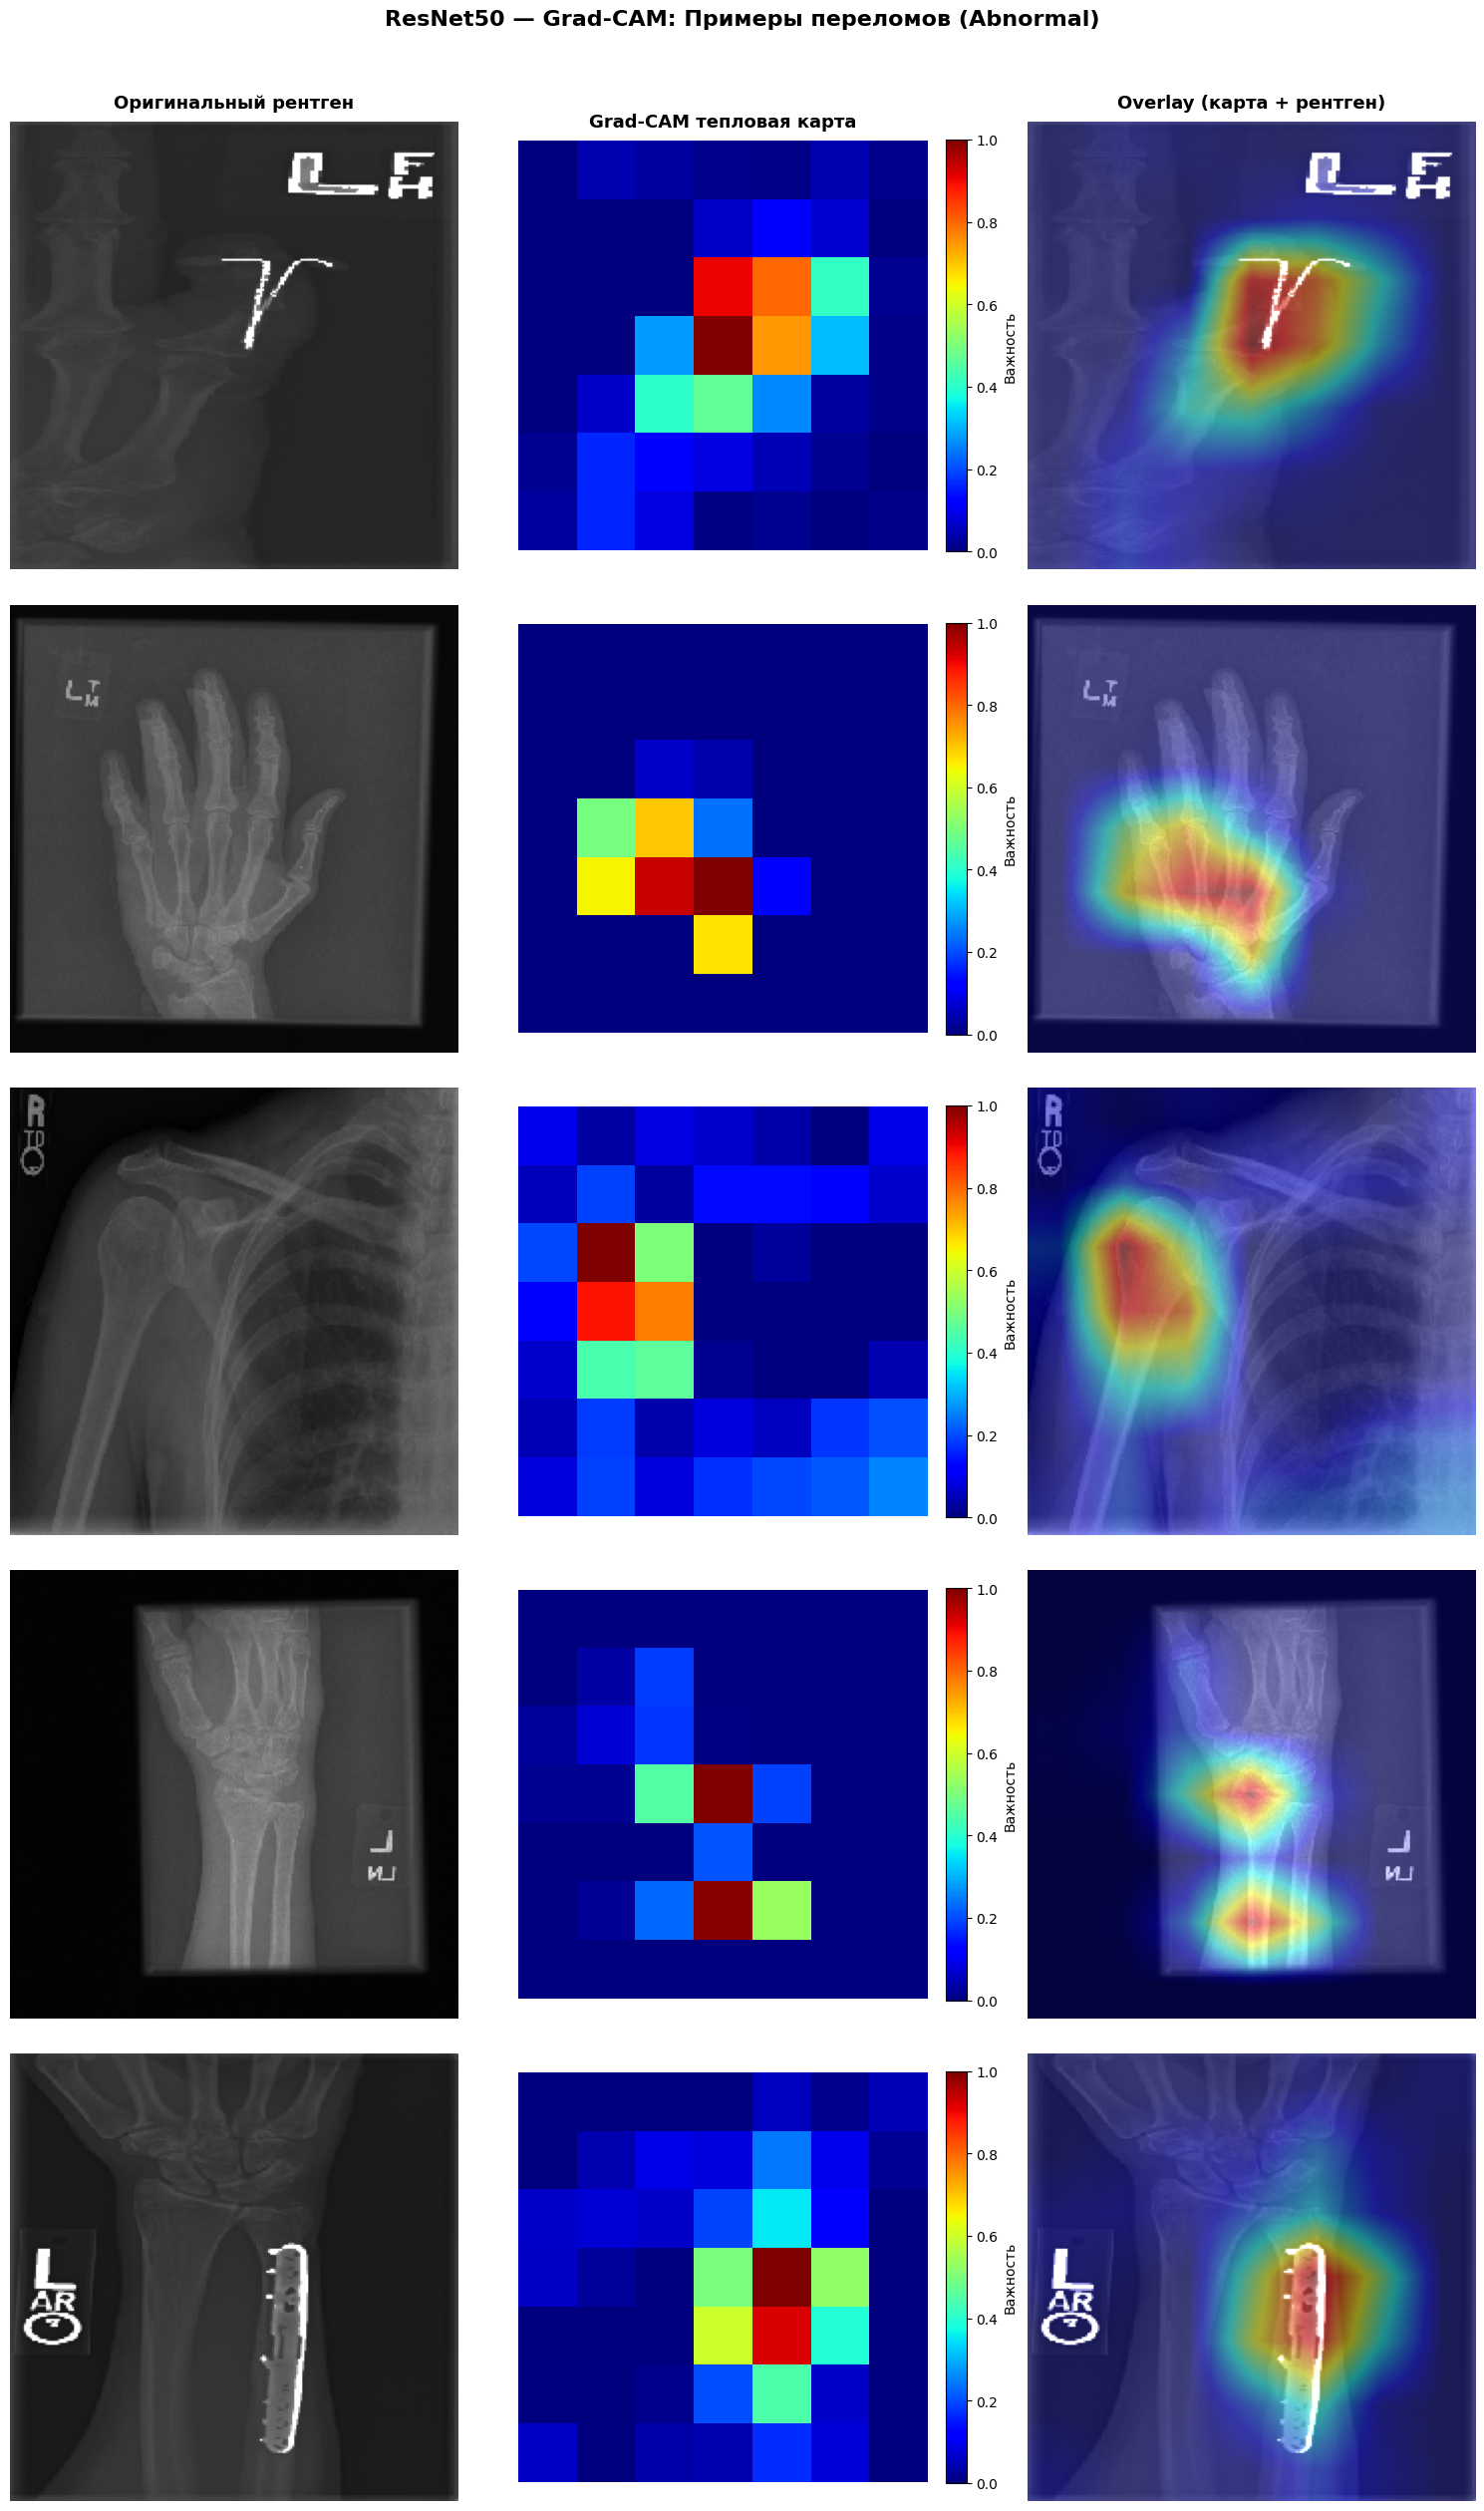

In [44]:
# ─── Примеры FRACTURE (Abnormal) ─────────────────────────────────────────────
print("Генерируем Grad-CAM для переломов (Abnormal)...")

abnormal_samples = get_samples(valid_df, DATA_DIR,
                                n_per_class=5, seed=42)
abnormal_samples = [s for s in abnormal_samples if s['label'] == 1]

visualize_gradcam_grid(
    samples    = abnormal_samples,
    model      = model,
    gradcam    = gradcam,
    title      = f'{MODEL_NAME} — Grad-CAM: Примеры переломов (Abnormal)',
    save_path  = f'{OUTPUT_DIR}/gradcam_fractures.png',
    threshold  = 0.35
)


Генерируем Grad-CAM для нормальных рентгенов (Normal)...
✓ Сохранено: /kaggle/working/gradcam_results/gradcam_normal.png


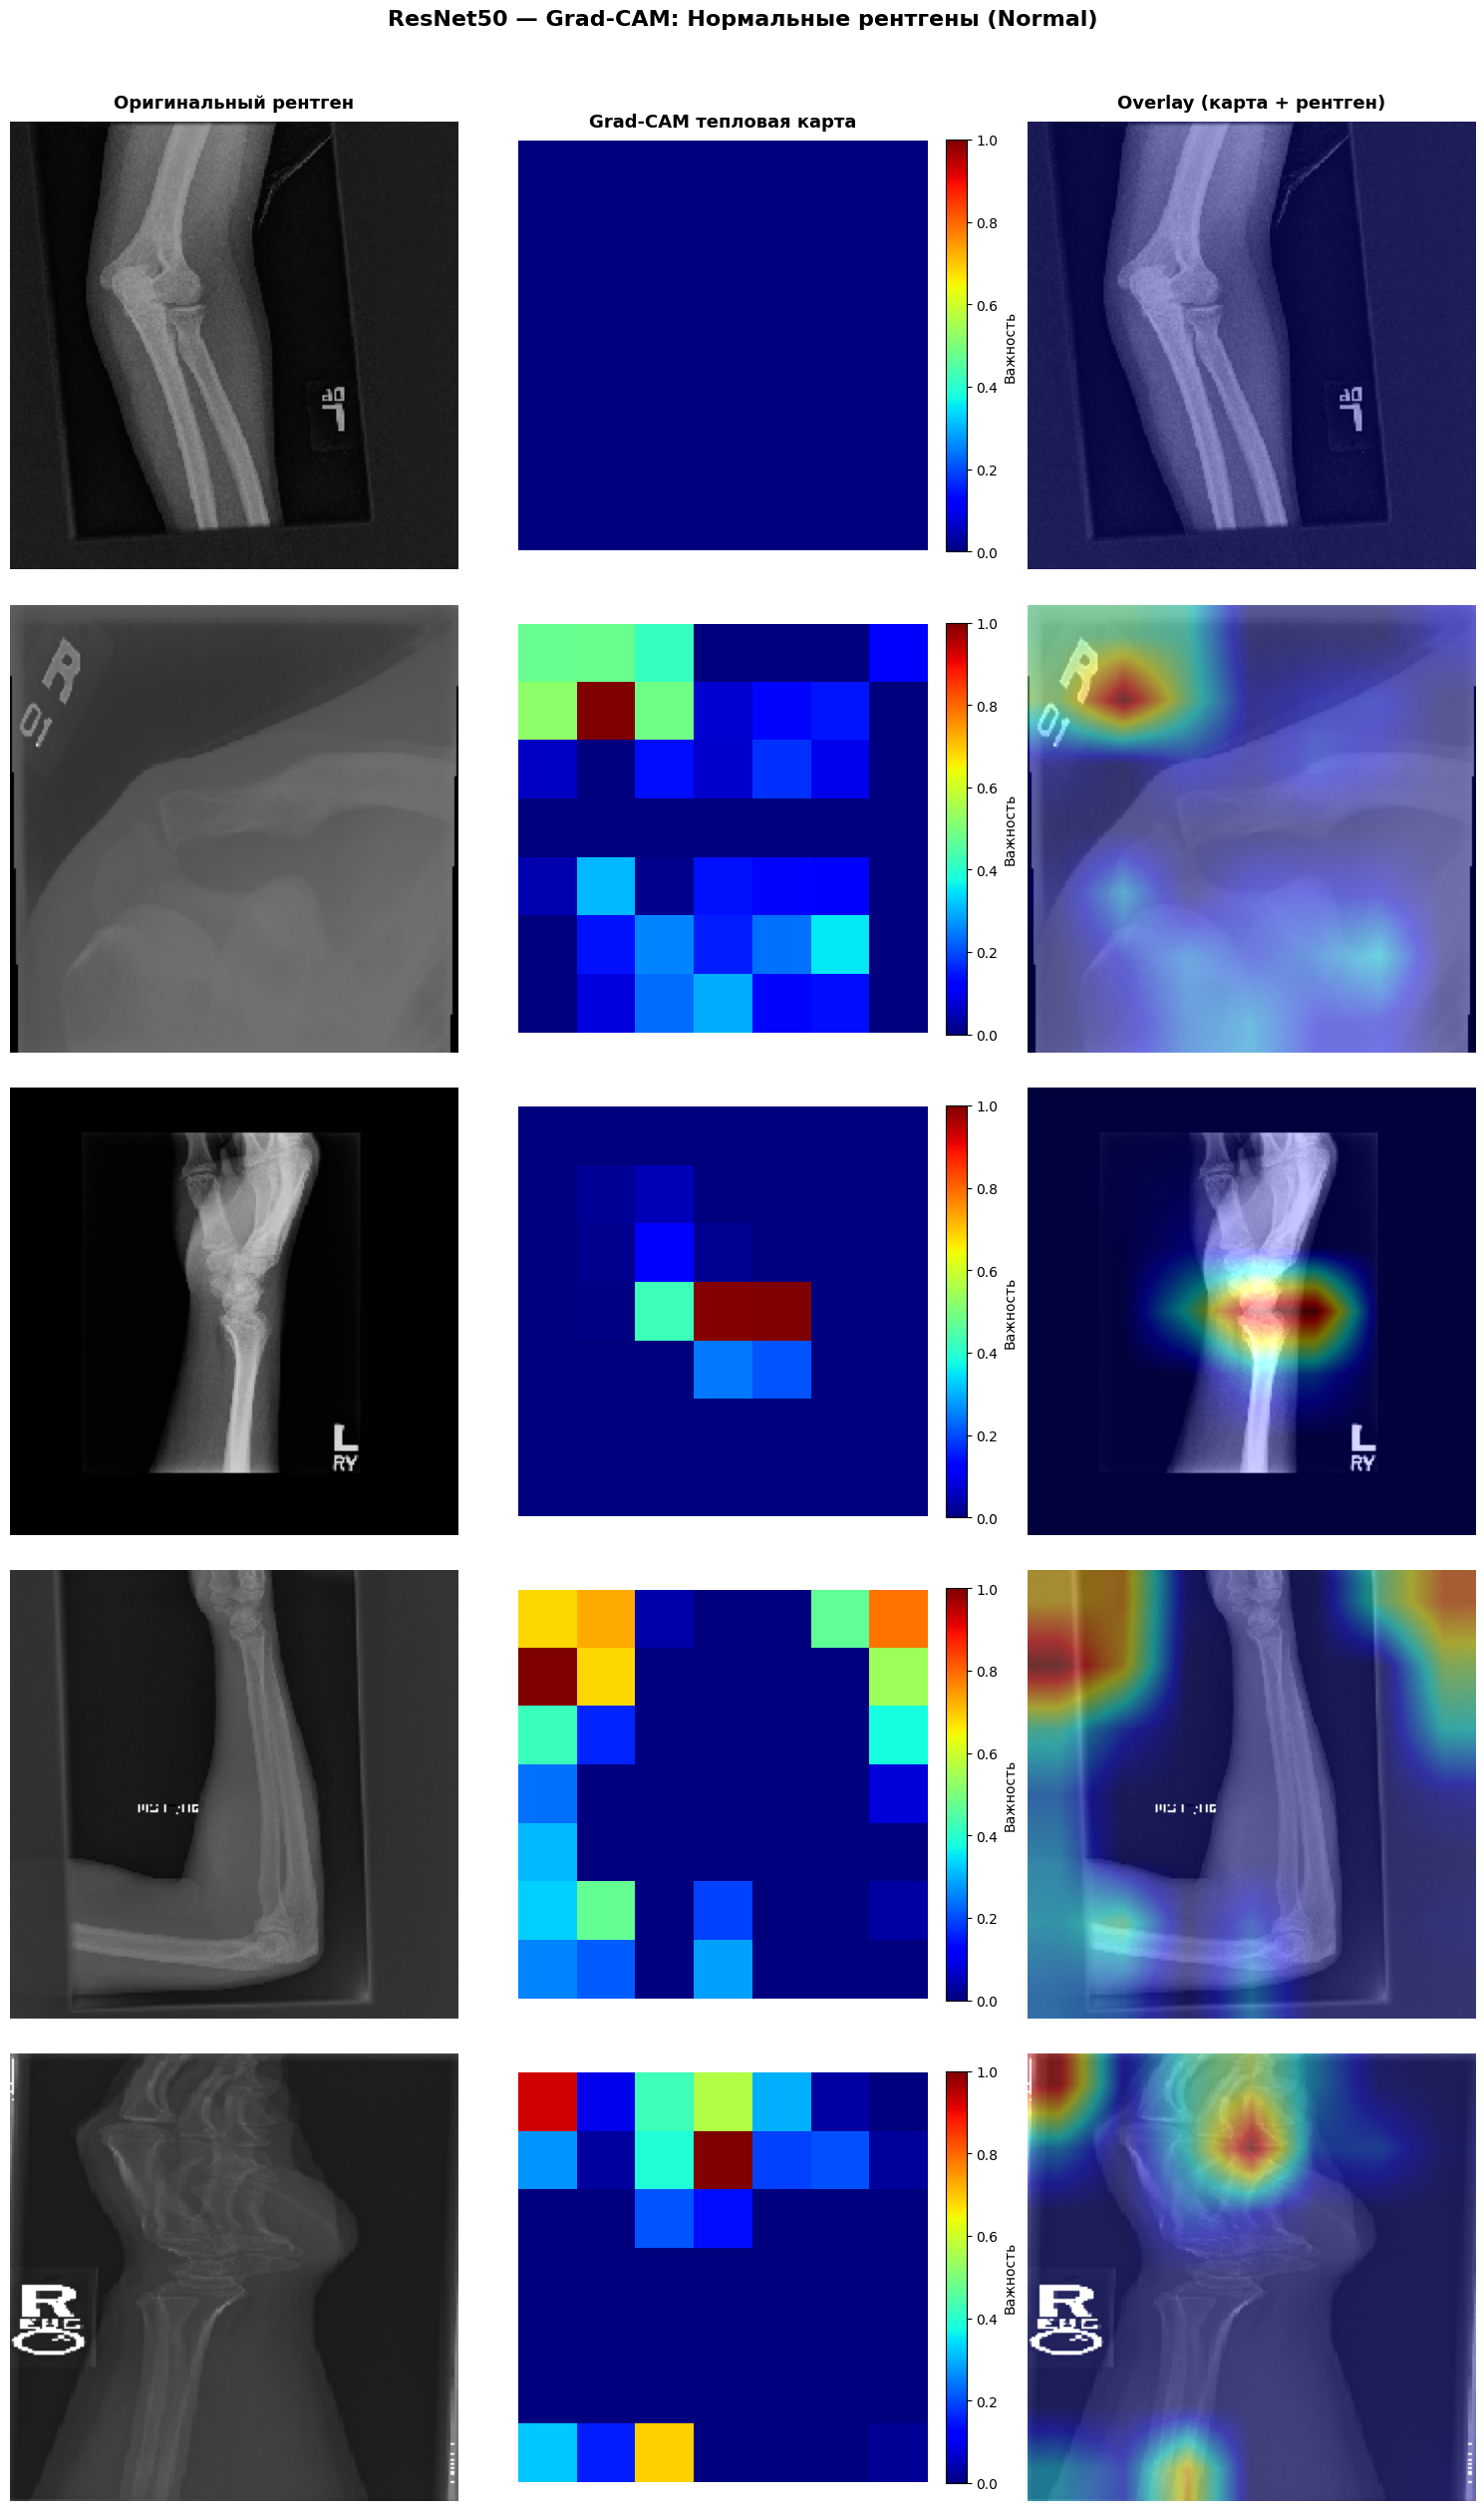

In [45]:
# ─── Примеры NORMAL ──────────────────────────────────────────────────────────
print("Генерируем Grad-CAM для нормальных рентгенов (Normal)...")

normal_samples = get_samples(valid_df, DATA_DIR,
                              n_per_class=5, seed=42)
normal_samples = [s for s in normal_samples if s['label'] == 0]

visualize_gradcam_grid(
    samples    = normal_samples,
    model      = model,
    gradcam    = gradcam,
    title      = f'{MODEL_NAME} — Grad-CAM: Нормальные рентгены (Normal)',
    save_path  = f'{OUTPUT_DIR}/gradcam_normal.png',
    threshold  = 0.35
)


## 7. Сравнение по частям тела

✓ Сохранено: /kaggle/working/gradcam_results/gradcam_wrist.png


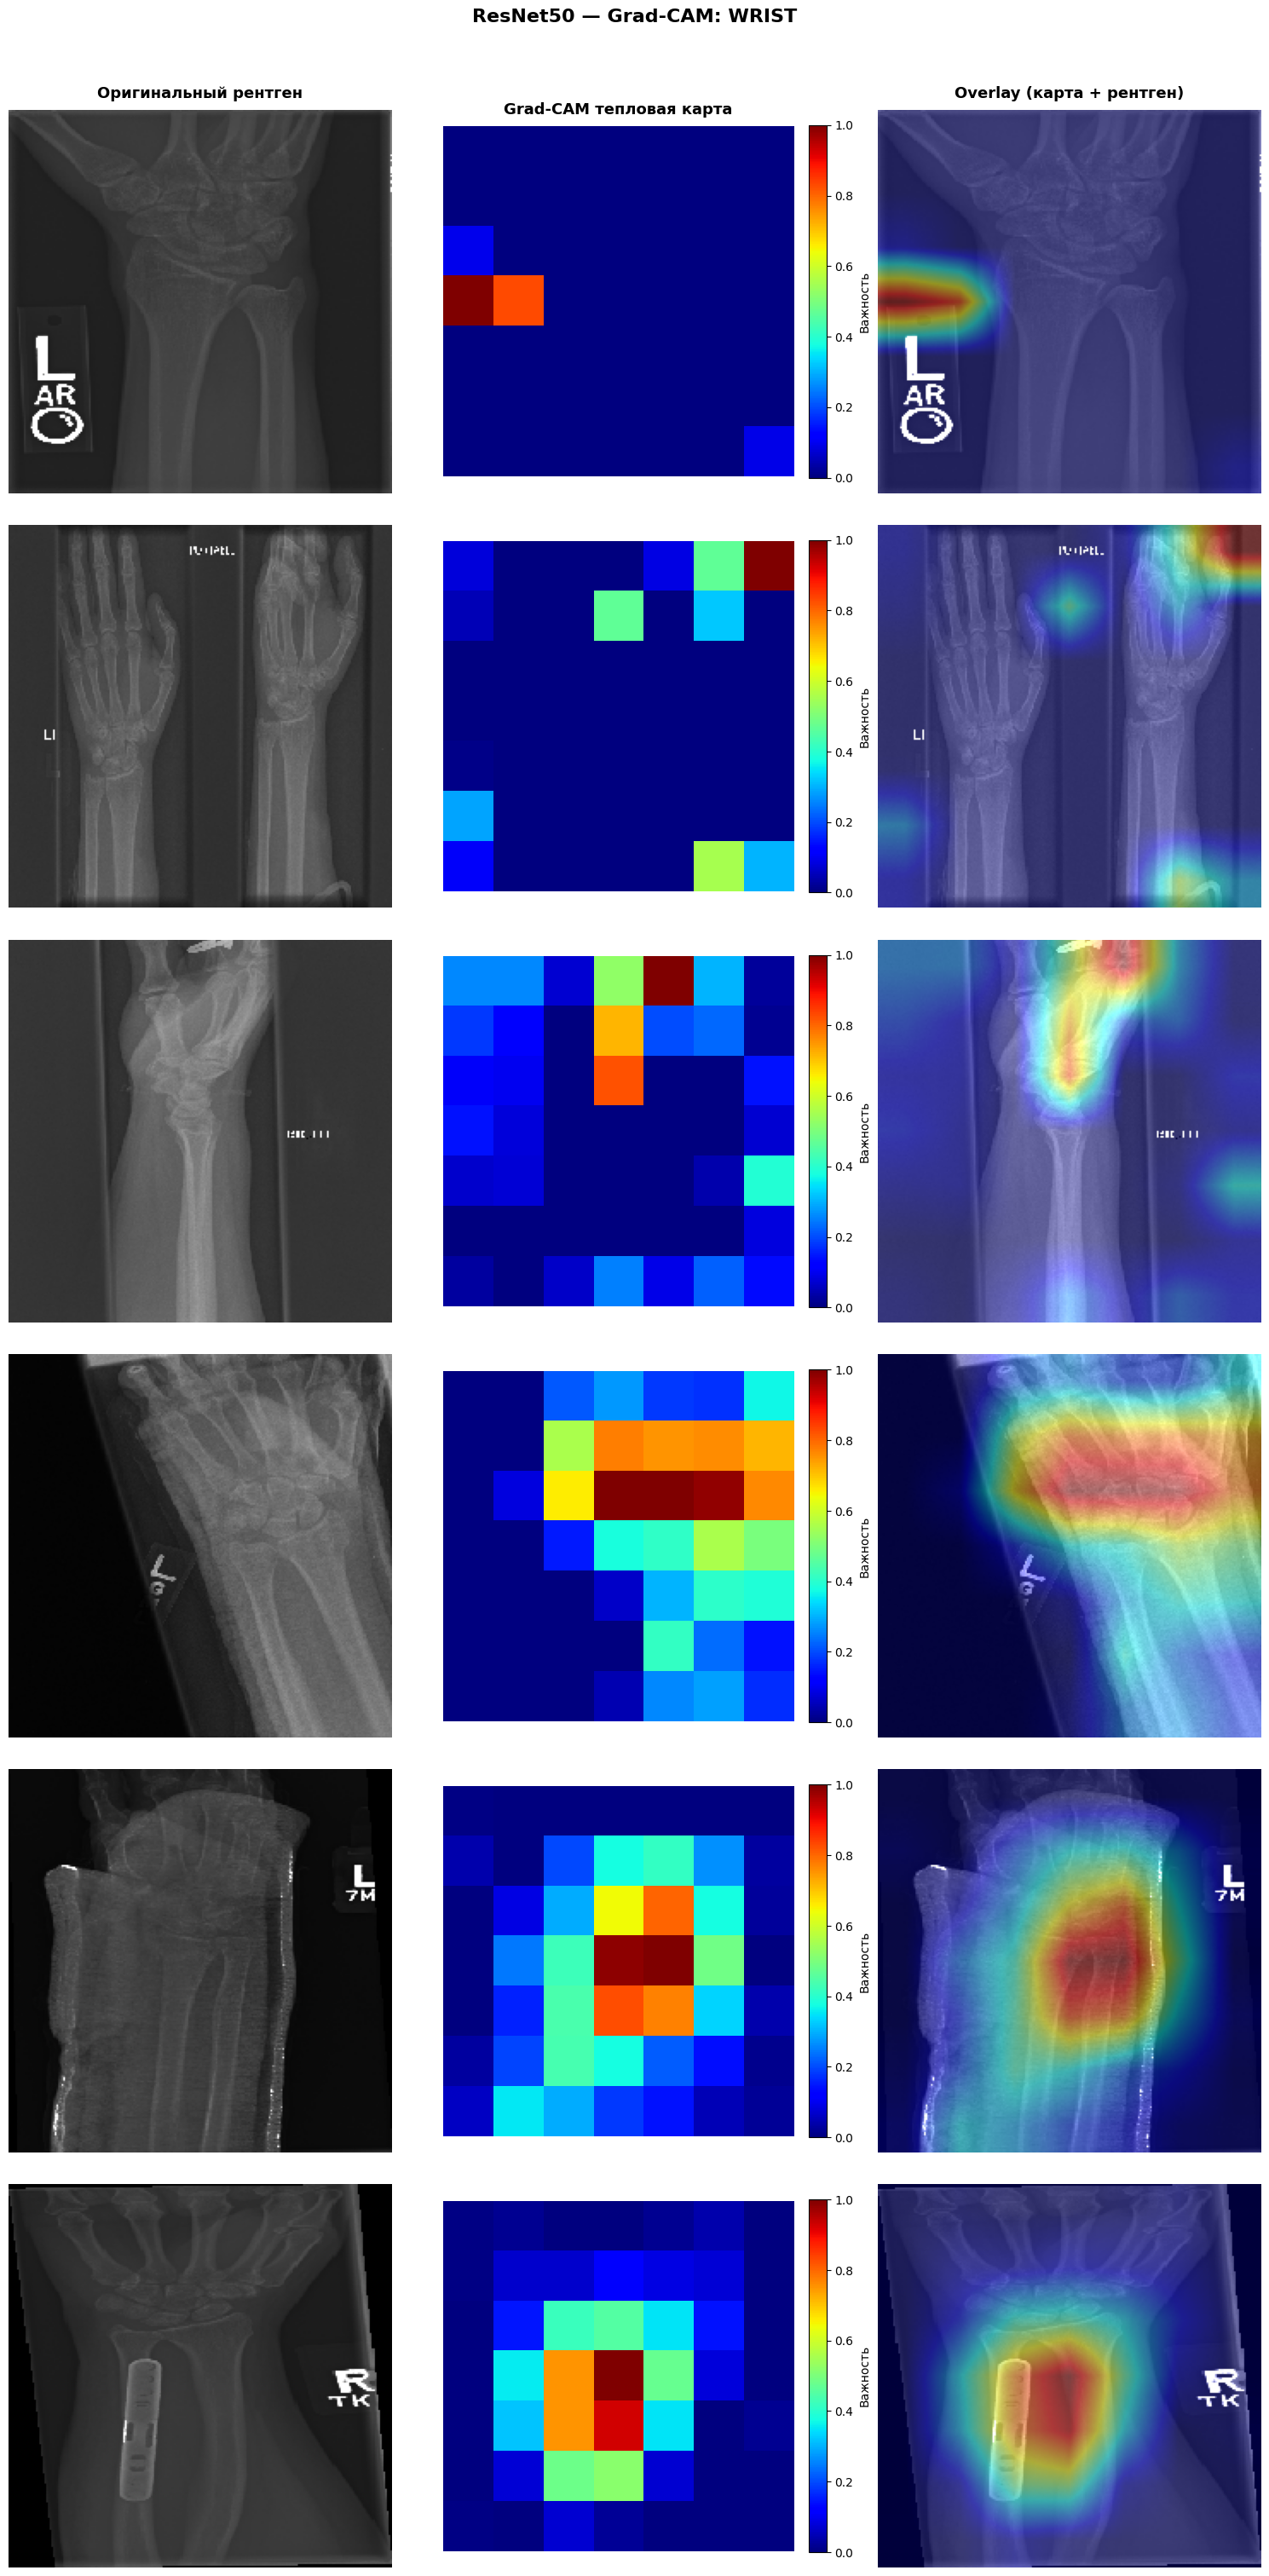

In [46]:
def visualize_by_body_part(valid_df, data_dir, model, gradcam,
                            body_part, n=3, threshold=0.35, save_path=None):
    """
    Показывает Grad-CAM для конкретной части тела:
    n примеров Normal + n примеров Abnormal.
    """
    part_df    = valid_df[valid_df['body_part'] == body_part]
    normal_df  = part_df[part_df['label'] == 0].sample(
        min(n, len(part_df[part_df['label']==0])), random_state=42)
    abnorm_df  = part_df[part_df['label'] == 1].sample(
        min(n, len(part_df[part_df['label']==1])), random_state=42)
    
    rows = []
    for _, row in pd.concat([normal_df, abnorm_df]).iterrows():
        path = data_dir / row['image_path_clean']
        if path.exists():
            rows.append({
                'path': path,
                'label': row['label'],
                'true_class': 'Normal' if row['label'] == 0 else 'Abnormal (Fracture)',
                'body_part': row['body_part']
            })
    
    part_clean = body_part.replace('XR_', '')
    visualize_gradcam_grid(
        samples   = rows,
        model     = model,
        gradcam   = gradcam,
        title     = f'{MODEL_NAME} — Grad-CAM: {part_clean}',
        save_path = save_path,
        threshold = threshold
    )


# Пример для запястья (WRIST) — самая частая часть тела в MURA
visualize_by_body_part(
    valid_df, DATA_DIR, model, gradcam,
    body_part  = 'XR_WRIST',
    n          = 3,
    threshold  = 0.35,
    save_path  = f'{OUTPUT_DIR}/gradcam_wrist.png'
)


Части тела в датасете: ['XR_WRIST', 'XR_FOREARM', 'XR_HAND', 'XR_HUMERUS', 'XR_SHOULDER', 'XR_ELBOW', 'XR_FINGER']

✓ Найдено 7 частей тела с примерами переломов

✓ Сохранено: /kaggle/working/gradcam_results/gradcam_all_body_parts.png


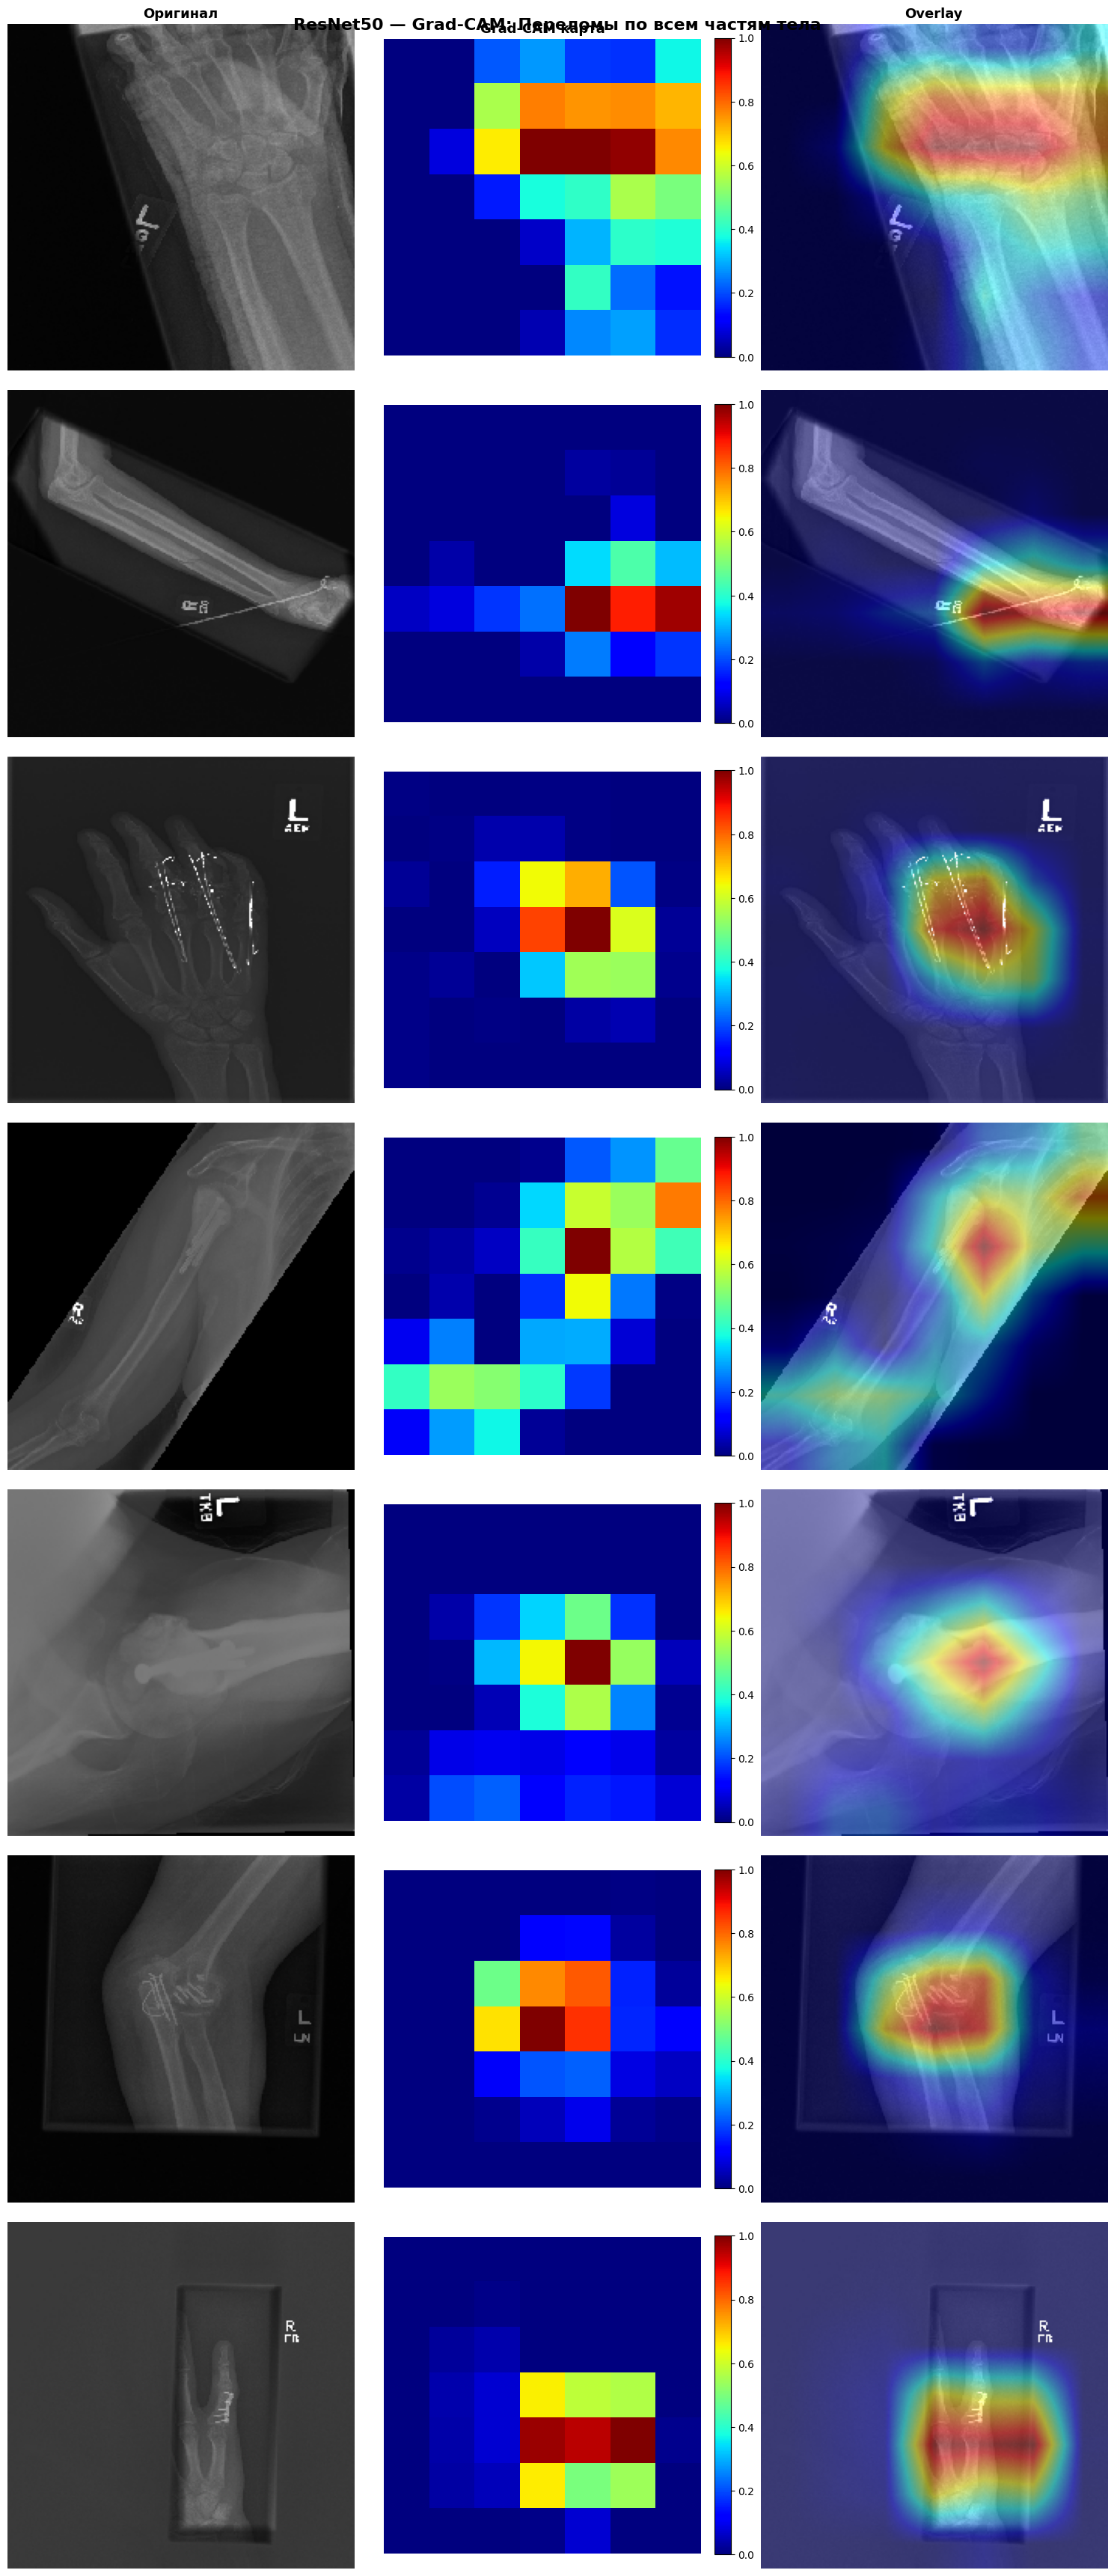

In [47]:
# ─── Обзор всех частей тела (1 пример каждая) ────────────────────────────────
body_parts = valid_df['body_part'].unique().tolist()
print(f"Части тела в датасете: {body_parts}")

rows_all = []
for bp in body_parts:
    bp_df = valid_df[(valid_df['body_part'] == bp) & (valid_df['label'] == 1)]
    if len(bp_df) == 0:
        continue
    row = bp_df.sample(1, random_state=42).iloc[0]
    path = DATA_DIR / row['image_path_clean']
    if path.exists():
        rows_all.append({
            'path': path, 'label': 1,
            'true_class': 'Abnormal (Fracture)',
            'body_part': row['body_part']
        })

print(f"\n✓ Найдено {len(rows_all)} частей тела с примерами переломов")

fig, axes = plt.subplots(len(rows_all), 3, figsize=(15, 5 * len(rows_all)))
fig.suptitle(f'{MODEL_NAME} — Grad-CAM: Переломы по всем частям тела',
             fontsize=16, fontweight='bold')

col_titles = ['Оригинал', 'Grad-CAM карта', 'Overlay']
for ax, ct in zip(axes[0], col_titles):
    ax.set_title(ct, fontsize=13, fontweight='bold')

for i, sample in enumerate(rows_all):
    orig, prep   = load_and_preprocess(sample['path'])
    result       = predict_single(model, prep, threshold=0.35)
    heatmap      = gradcam.compute_heatmap(prep)
    colored, ov  = gradcam.overlay_heatmap(heatmap, orig, alpha=ALPHA_OVERLAY)
    
    bp = sample['body_part'].replace('XR_', '')
    conf = result['confidence']
    pred = result['label']
    
    axes[i][0].set_ylabel(f"{bp}\nP(fracture)={result['prob_abnormal']:.2f}",
                           fontsize=10, fontweight='bold', rotation=0,
                           labelpad=110, va='center')
    axes[i][0].imshow(orig); axes[i][0].axis('off')
    im = axes[i][1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
    axes[i][1].axis('off')
    plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04)
    axes[i][2].imshow(ov); axes[i][2].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/gradcam_all_body_parts.png',
            dpi=200, bbox_inches='tight', facecolor='white')
print(f"\n✓ Сохранено: {OUTPUT_DIR}/gradcam_all_body_parts.png")
plt.show()


## 8. Анализ ошибок — False Positives & False Negatives

In [48]:
def find_fp_fn(valid_df, data_dir, model, n=3, threshold=0.35):
    """
    Находит примеры False Positive (Normal → Abnormal)
    и False Negative (Abnormal → Normal) для анализа ошибок.
    """
    fps, fns = [], []
    
    sampled = valid_df.sample(min(300, len(valid_df)), random_state=42)
    
    for _, row in sampled.iterrows():
        if len(fps) >= n and len(fns) >= n:
            break
        
        path = data_dir / row['image_path_clean']
        if not path.exists():
            continue
        
        _, prep  = load_and_preprocess(path)
        result   = predict_single(model, prep, threshold=threshold)
        pred_lbl = 1 if 'Abnormal' in result['label'] else 0
        
        if row['label'] == 0 and pred_lbl == 1 and len(fps) < n:
            fps.append({'path': path, 'label': 0,
                        'true_class': 'Normal',
                        'pred': result, 'body_part': row['body_part'],
                        'error_type': 'False Positive'})
        
        elif row['label'] == 1 and pred_lbl == 0 and len(fns) < n:
            fns.append({'path': path, 'label': 1,
                        'true_class': 'Abnormal (Fracture)',
                        'pred': result, 'body_part': row['body_part'],
                        'error_type': 'False Negative'})
    
    print(f"Найдено FP: {len(fps)}, FN: {len(fns)}")
    return fps, fns


print("Ищем примеры ошибочных предсказаний...")
fps, fns = find_fp_fn(valid_df, DATA_DIR, model, n=3, threshold=0.35)


Ищем примеры ошибочных предсказаний...
Найдено FP: 3, FN: 3


✓ Сохранено: /kaggle/working/gradcam_results/gradcam_false_positives.png


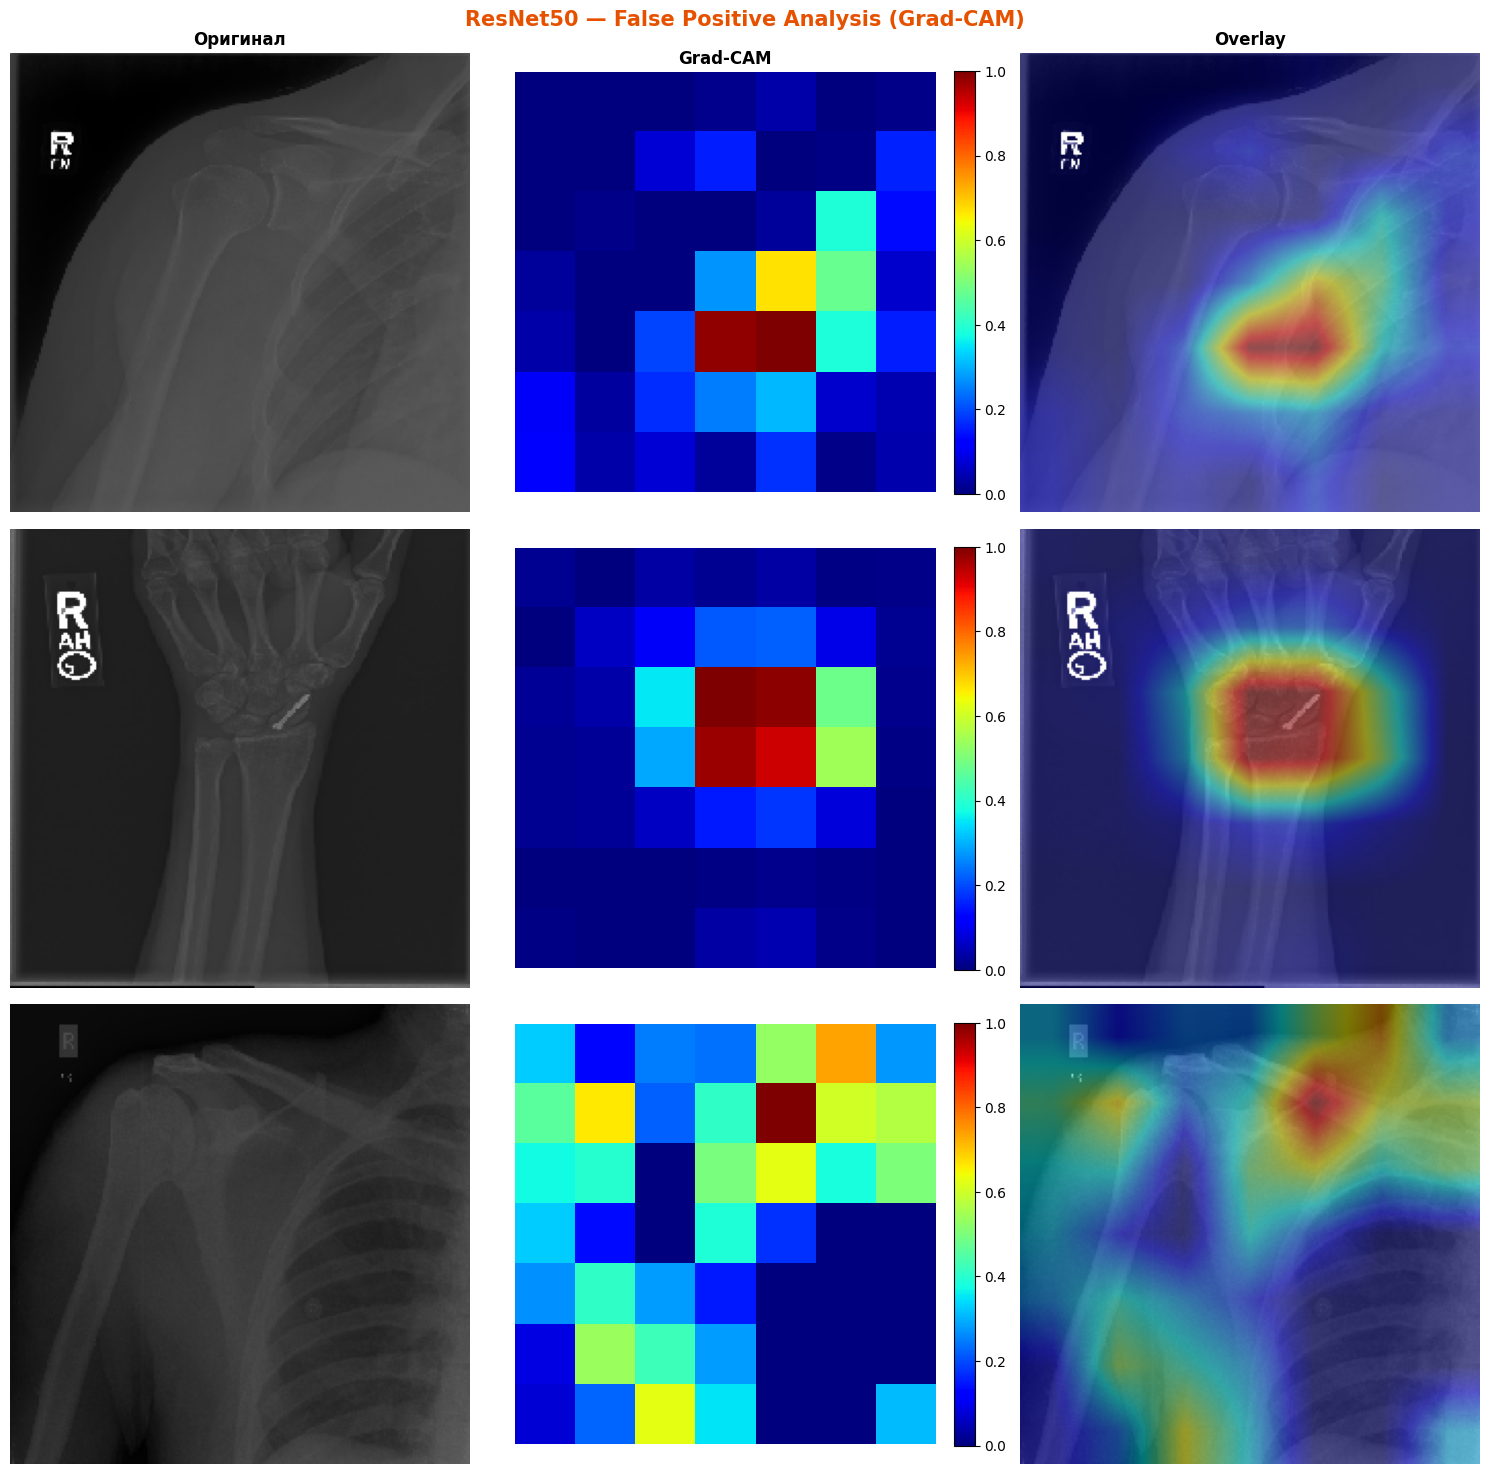

✓ Сохранено: /kaggle/working/gradcam_results/gradcam_false_negatives.png


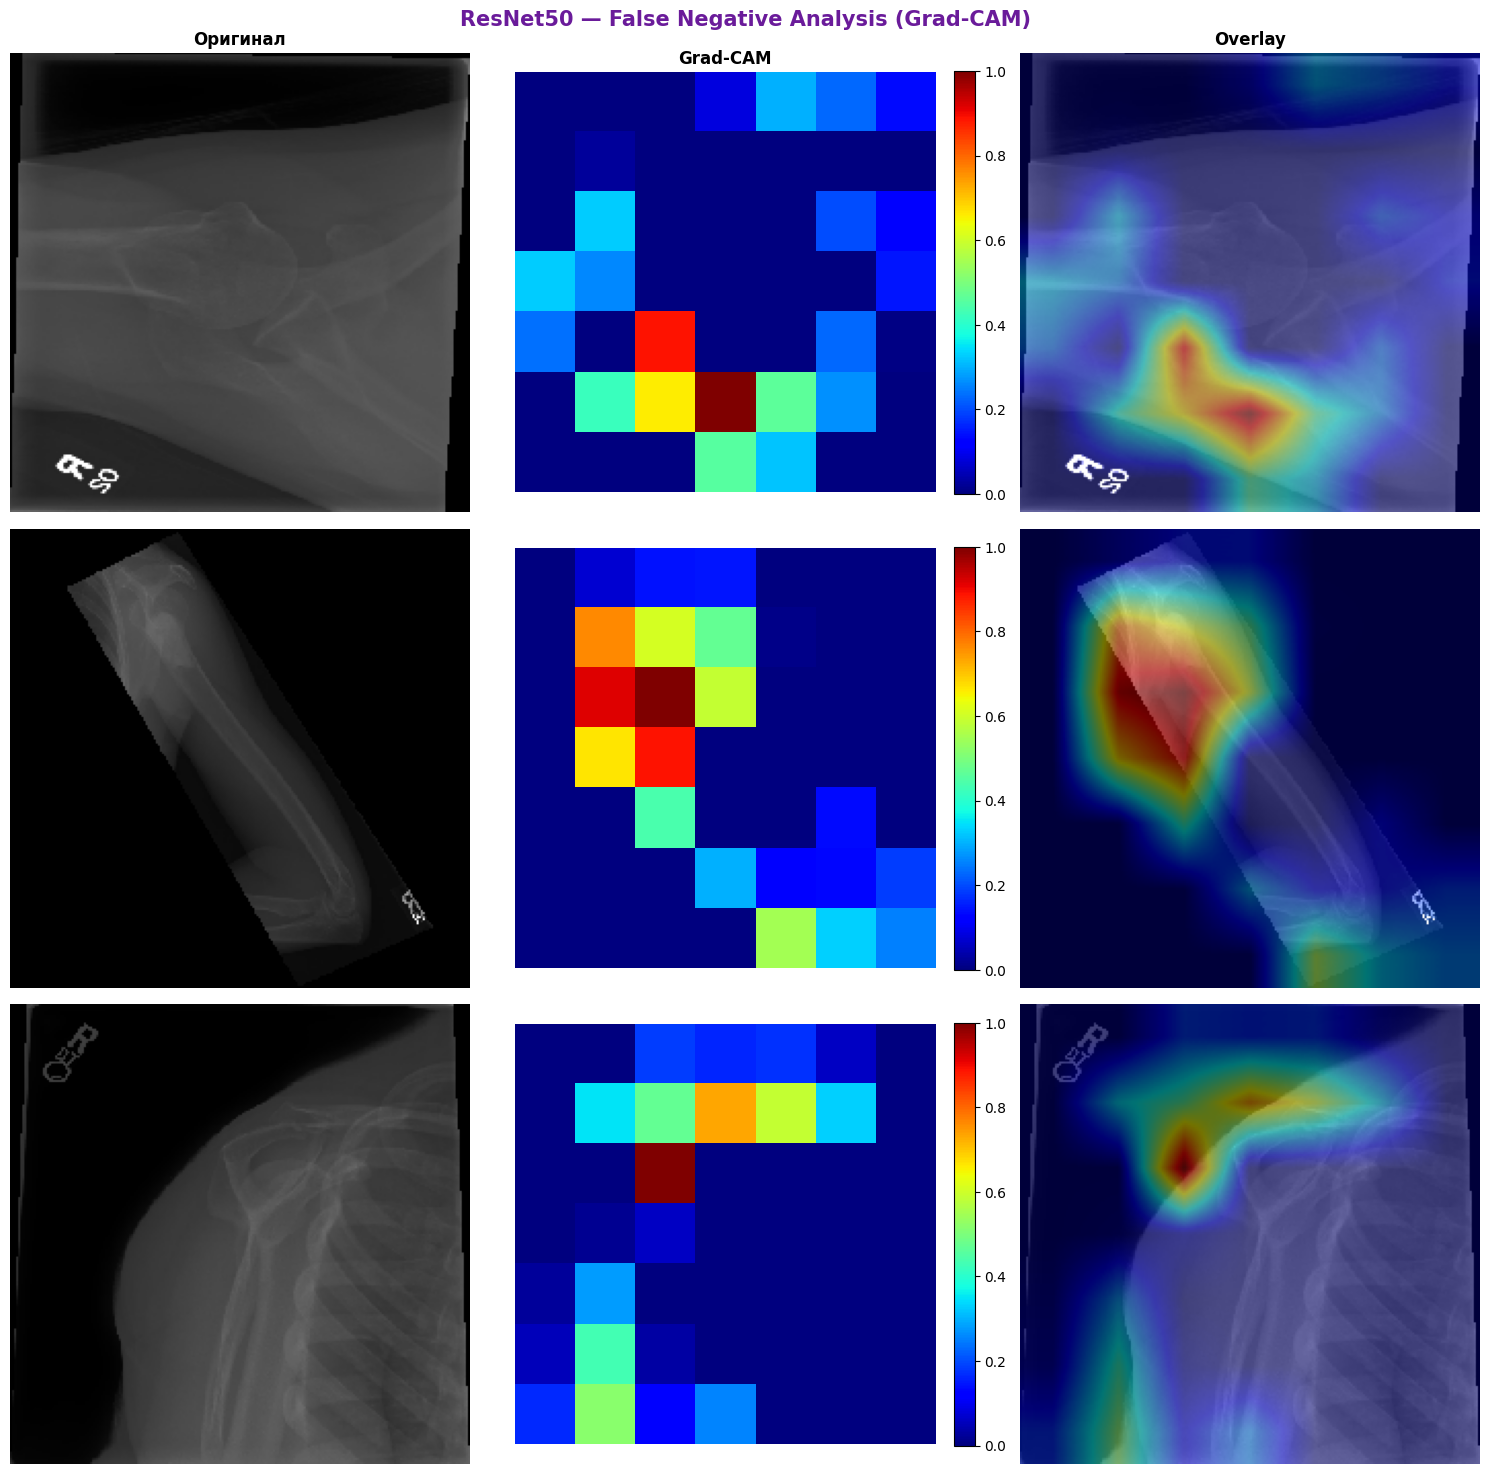

In [49]:
def visualize_errors(error_samples, model, gradcam, error_type,
                     save_path=None, threshold=0.35):
    """Визуализирует ошибки модели с Grad-CAM."""
    if not error_samples:
        print(f"Нет примеров {error_type}")
        return
    
    n = len(error_samples)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1:
        axes = [axes]
    
    color = '#e65100' if 'False Positive' in error_type else '#6a1b9a'
    fig.suptitle(f'{MODEL_NAME} — {error_type} Analysis (Grad-CAM)',
                 fontsize=15, fontweight='bold', color=color)
    
    for ax, ct in zip(axes[0],
                      ['Оригинал', 'Grad-CAM', 'Overlay']):
        ax.set_title(ct, fontsize=12, fontweight='bold')
    
    for i, sample in enumerate(error_samples):
        orig, prep   = load_and_preprocess(sample['path'])
        heatmap      = gradcam.compute_heatmap(prep)
        colored, ov  = gradcam.overlay_heatmap(heatmap, orig, alpha=ALPHA_OVERLAY)
        
        result    = sample['pred']
        bp        = sample['body_part'].replace('XR_', '')
        prob_abn  = result['prob_abnormal']
        
        err_type = sample['error_type']
        note = ('Модель видит перелом там, где его нет' if 'FP' in err_type or 'Positive' in err_type
                else 'Модель пропустила перелом')
        
        axes[i][0].set_ylabel(
            f"{bp}\nИстина: {sample['true_class']}\n"
            f"P(fracture)={prob_abn:.2f}\n{note}",
            fontsize=8, rotation=0, labelpad=130,
            va='center', color=color, fontweight='bold'
        )
        axes[i][0].imshow(orig); axes[i][0].axis('off')
        im = axes[i][1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        axes[i][1].axis('off')
        plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04)
        axes[i][2].imshow(ov); axes[i][2].axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
        print(f"✓ Сохранено: {save_path}")
    plt.show()


# Визуализируем FP (False Positives)
visualize_errors(fps, model, gradcam, 'False Positive',
                 save_path=f'{OUTPUT_DIR}/gradcam_false_positives.png')

# Визуализируем FN (False Negatives)
visualize_errors(fns, model, gradcam, 'False Negative',
                 save_path=f'{OUTPUT_DIR}/gradcam_false_negatives.png')


## 9. Итоговая сводная визуализация для диплома

✓ Дипломная фигура сохранена: /kaggle/working/gradcam_results/gradcam_diploma_figure.png


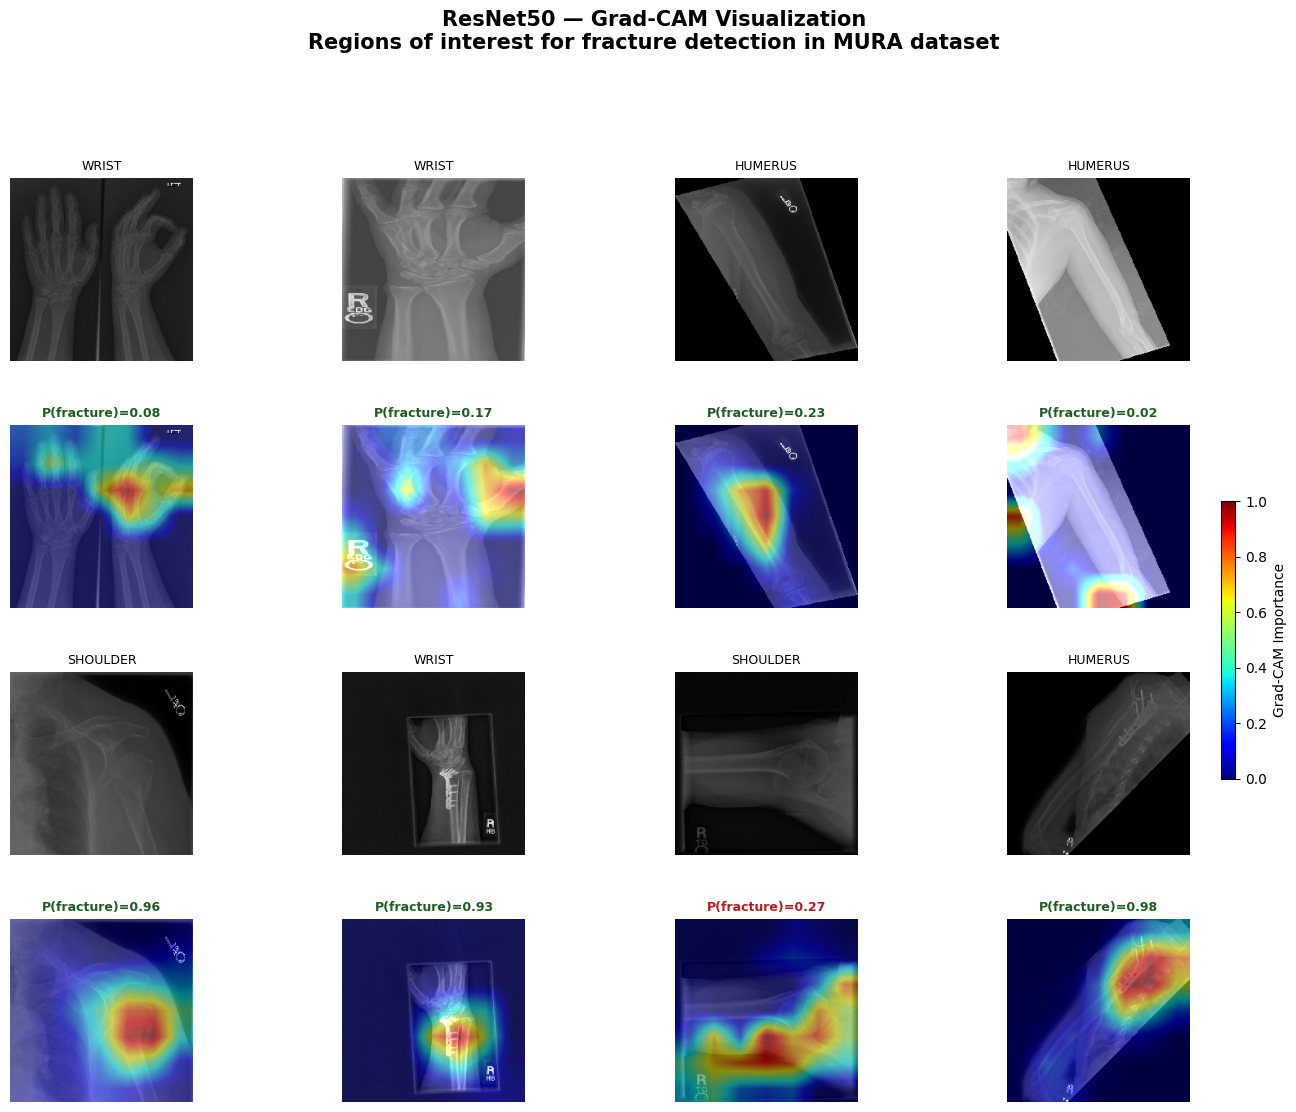

In [50]:
def create_diploma_figure(valid_df, data_dir, model, gradcam,
                          n_each=4, threshold=0.35, save_path=None):
    """
    Создаёт итоговую красивую фигуру для диплома:
    Верхний ряд  — Normal (нет перелома)
    Нижний ряд   — Abnormal (перелом)
    Для каждого: Оригинал + Overlay рядом
    """
    all_s = get_samples(valid_df, data_dir, n_per_class=n_each, seed=7)
    normals  = [s for s in all_s if s['label'] == 0][:n_each]
    abnormals= [s for s in all_s if s['label'] == 1][:n_each]
    
    fig = plt.figure(figsize=(n_each * 5, 12))
    fig.suptitle(
        f'{MODEL_NAME} — Grad-CAM Visualization\n'
        'Regions of interest for fracture detection in MURA dataset',
        fontsize=15, fontweight='bold', y=1.02
    )
    
    gs = fig.add_gridspec(4, n_each, hspace=0.35, wspace=0.15)
    
    row_labels = ['Normal\n(Original)', 'Normal\n(Grad-CAM)',
                  'Fracture\n(Original)', 'Fracture\n(Grad-CAM)']
    
    for row_i, (row_samples, start_label) in enumerate(
        [(normals, 0), (abnormals, 2)]
    ):
        for col_i, sample in enumerate(row_samples):
            orig, prep   = load_and_preprocess(sample['path'])
            result       = predict_single(model, prep, threshold=threshold)
            heatmap      = gradcam.compute_heatmap(prep)
            _, ov        = gradcam.overlay_heatmap(heatmap, orig, alpha=0.5)
            
            bp   = sample['body_part'].replace('XR_', '')
            prob = result['prob_abnormal']
            
            # Оригинал
            ax_orig = fig.add_subplot(gs[start_label, col_i])
            ax_orig.imshow(orig)
            ax_orig.axis('off')
            ax_orig.set_title(f'{bp}', fontsize=9)
            
            # Overlay
            ax_ov = fig.add_subplot(gs[start_label + 1, col_i])
            ax_ov.imshow(ov)
            ax_ov.axis('off')
            c = '#1b5e20' if (sample['label'] == 0 and prob < threshold) or \
                             (sample['label'] == 1 and prob >= threshold) else '#b71c1c'
            ax_ov.set_title(f'P(fracture)={prob:.2f}', fontsize=9,
                            color=c, fontweight='bold')
            
            if col_i == 0:
                label_r = 'Normal' if start_label == 0 else 'Fracture'
                ax_orig.set_ylabel(f'{label_r}\nOriginal',
                                   fontsize=10, fontweight='bold')
                ax_ov.set_ylabel(f'{label_r}\nGrad-CAM',
                                 fontsize=10, fontweight='bold')
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='jet',
                                norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=fig.get_axes(), shrink=0.3, aspect=20,
                        pad=0.02, location='right')
    cbar.set_label('Grad-CAM Importance', fontsize=10)
    
    if save_path:
        plt.savefig(save_path, dpi=250, bbox_inches='tight', facecolor='white')
        print(f"✓ Дипломная фигура сохранена: {save_path}")
    plt.show()


create_diploma_figure(
    valid_df, DATA_DIR, model, gradcam,
    n_each     = 4,
    threshold  = 0.35,
    save_path  = f'{OUTPUT_DIR}/gradcam_diploma_figure.png'
)


## 10. Статистический анализ тепловых карт

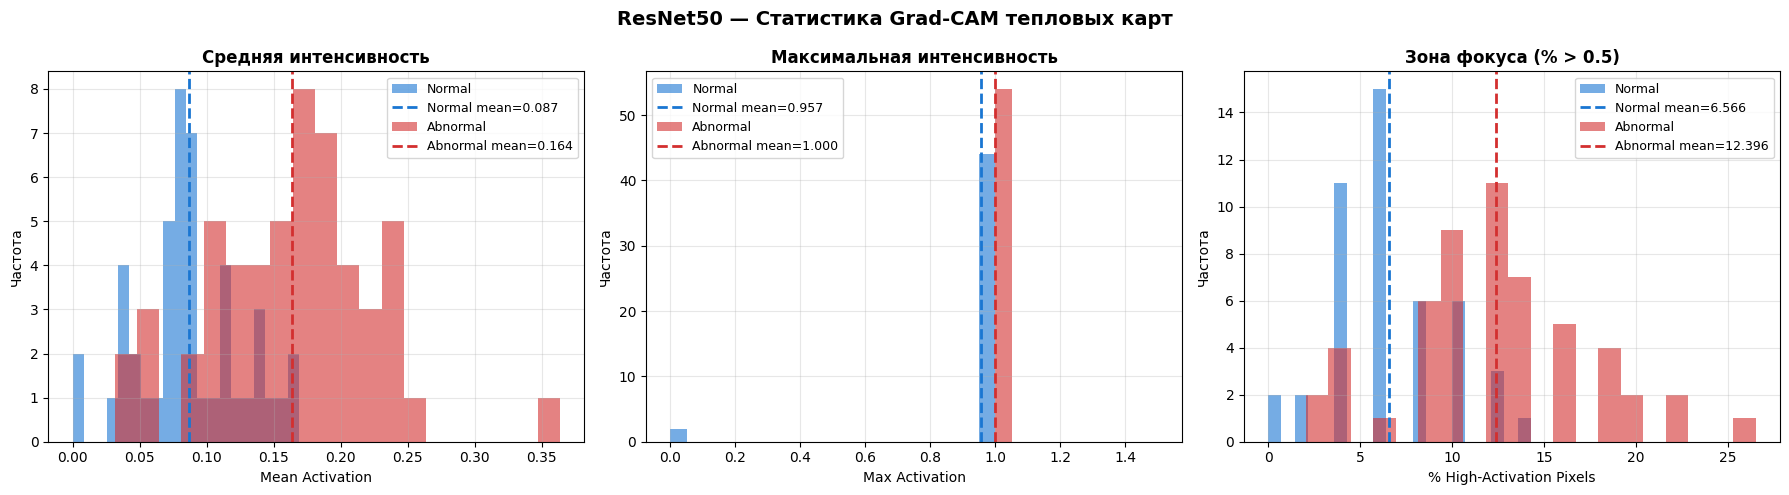


Статистика по группам:
         mean_intensity                                                  \
                  count    mean     std     min     25%     50%     75%   
label                                                                     
Abnormal           54.0  0.1639  0.0623  0.0314  0.1193  0.1738  0.1980   
Normal             46.0  0.0867  0.0398  0.0000  0.0707  0.0833  0.1109   

                 max_intensity          ...           focus_area_pct           \
             max         count    mean  ...  75%  max          count     mean   
label                                   ...                                     
Abnormal  0.3633          54.0  1.0000  ...  1.0  1.0           54.0  12.3961   
Normal    0.1690          46.0  0.9565  ...  1.0  1.0           46.0   6.5661   

                                                              
             std     min      25%      50%      75%      max  
label                                                         
Abnor

In [51]:
def analyze_heatmap_statistics(valid_df, data_dir, model, gradcam,
                                n=100, threshold=0.35):
    """
    Анализирует статистику тепловых карт:
    Среднее, медиана интенсивности для Normal vs Abnormal.
    """
    stats = {'label': [], 'mean_intensity': [],
             'max_intensity': [], 'focus_area_pct': []}
    
    sample = valid_df.sample(min(n, len(valid_df)), random_state=42)
    
    for _, row in sample.iterrows():
        path = data_dir / row['image_path_clean']
        if not path.exists():
            continue
        
        _, prep  = load_and_preprocess(path)
        heatmap  = gradcam.compute_heatmap(prep)
        
        stats['label'].append('Normal' if row['label'] == 0 else 'Abnormal')
        stats['mean_intensity'].append(float(heatmap.mean()))
        stats['max_intensity'].append(float(heatmap.max()))
        # % пикселей с интенсивностью > 0.5 (зона "фокуса")
        stats['focus_area_pct'].append(float((heatmap > 0.5).mean() * 100))
    
    stats_df = pd.DataFrame(stats)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{MODEL_NAME} — Статистика Grad-CAM тепловых карт',
                 fontsize=14, fontweight='bold')
    
    metrics = [
        ('mean_intensity',  'Средняя интенсивность',  'Mean Activation'),
        ('max_intensity',   'Максимальная интенсивность', 'Max Activation'),
        ('focus_area_pct',  'Зона фокуса (% > 0.5)', '% High-Activation Pixels'),
    ]
    
    colors = {'Normal': '#1976D2', 'Abnormal': '#D32F2F'}
    
    for ax, (col, title, ylabel) in zip(axes, metrics):
        for lbl, color in colors.items():
            vals = stats_df[stats_df['label'] == lbl][col]
            ax.hist(vals, bins=20, alpha=0.6, label=lbl, color=color)
            ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=2,
                       label=f'{lbl} mean={vals.mean():.3f}')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel(ylabel)
        ax.set_ylabel('Частота')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/gradcam_statistics.png',
                dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print("\nСтатистика по группам:")
    print(stats_df.groupby('label')[
        ['mean_intensity', 'max_intensity', 'focus_area_pct']
    ].describe().round(4))
    
    stats_df.to_csv(f'{OUTPUT_DIR}/gradcam_stats.csv', index=False)
    print(f"\n✓ Статистика сохранена: {OUTPUT_DIR}/gradcam_stats.csv")
    return stats_df


stats_df = analyze_heatmap_statistics(valid_df, DATA_DIR, model, gradcam, n=100)


## 11. Итоги

In [52]:
import glob

print("=" * 60)
print(f"ЗАДАЧА 5 — GRAD-CAM ВИЗУАЛИЗАЦИЯ — ЗАВЕРШЕНА")
print("=" * 60)
print(f"\nМодель: {MODEL_NAME}")
print(f"Метод:  Grad-CAM (Selvaraju et al., 2017)")
print(f"Слой:   {LAST_CONV_LAYER}")
print()
print("Сохранённые файлы:")
for f in sorted(glob.glob(f'{OUTPUT_DIR}/*.png') + 
                glob.glob(f'{OUTPUT_DIR}/*.csv')):
    size_kb = os.path.getsize(f) / 1024
    print(f"  ✓ {os.path.basename(f):45s} {size_kb:.1f} KB")

print()
print("Что было сделано:")
print("  1. Реализован алгоритм Grad-CAM для интерпретации модели")
print("  2. Тепловые карты для примеров fracture (Abnormal)")
print("  3. Тепловые карты для примеров normal")
print("  4. Сравнение по всем 7 частям тела MURA")
print("  5. Анализ ошибок FP и FN с визуализацией")
print("  6. Итоговая фигура для диплома")
print("  7. Статистический анализ активаций")
print()
print("Следующий шаг: Задача 6 — Веб-прототип системы")


ЗАДАЧА 5 — GRAD-CAM ВИЗУАЛИЗАЦИЯ — ЗАВЕРШЕНА

Модель: ResNet50
Метод:  Grad-CAM (Selvaraju et al., 2017)
Слой:   conv5_block3_out

Сохранённые файлы:
  ✓ gradcam_all_body_parts.png                    1111.0 KB
  ✓ gradcam_diploma_figure.png                    1938.7 KB
  ✓ gradcam_false_negatives.png                   399.2 KB
  ✓ gradcam_false_positives.png                   514.7 KB
  ✓ gradcam_fractures.png                         795.5 KB
  ✓ gradcam_normal.png                            702.9 KB
  ✓ gradcam_statistics.png                        135.9 KB
  ✓ gradcam_stats.csv                             4.9 KB
  ✓ gradcam_wrist.png                             1007.0 KB

Что было сделано:
  1. Реализован алгоритм Grad-CAM для интерпретации модели
  2. Тепловые карты для примеров fracture (Abnormal)
  3. Тепловые карты для примеров normal
  4. Сравнение по всем 7 частям тела MURA
  5. Анализ ошибок FP и FN с визуализацией
  6. Итоговая фигура для диплома
  7. Статистический анализ ак